In [1]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import ipywidgets as widget
from XRootD import client
import xsec
import os
import tqdm

Welcome to JupyROOT 6.28/06


In [2]:
ROOT.gInterpreter.Declare("""
float compute_weight_ttbar( float norm, float pileupWeight, float pileupJetIDWeight, float topPtWeight13TeV, float lepIdSF, float isoSF, float L1NonPrefiringProb_CommonCalc, float MCWeight_MultiLepCalc, float tthfWeight, float btagDeepJetWeight, float btagDeepJet2DWeight_HTnj ){
    return norm * pileupWeight * pileupJetIDWeight * topPtWeight13TeV * lepIdSF * isoSF * L1NonPrefiringProb_CommonCalc * ( MCWeight_MultiLepCalc / abs( MCWeight_MultiLepCalc ) ) * btagDeepJetWeight * btagDeepJet2DWeight_HTnj;
}
""")

True

In [3]:
year = widget.Dropdown( options = [ "2016APV", "2016", "2017", "2018" ], value = "2017" )
year

Dropdown(index=2, options=('2016APV', '2016', '2017', '2018'), value='2017')

In [4]:
bruxPrefix = "root://brux30.hep.brown.edu:1094/"
samples = {
    "DataE": {},
    "DataM": {},
    "ttbar": {}
}

step2Dir = "/store/user/dali/FWLJMET106XUL_singleLep{}UL_RunIISummer20_3t_step1hadds/nominal/".format( year.value )
xrdClient = client.FileSystem( bruxPrefix )
status, dirList = xrdClient.dirlist( step2Dir )
samples[ "DataE" ] = [ item.name for item in dirList if ( "SingleElectron" in item.name or "EGamma" in item.name ) ]
samples[ "DataM" ] = [ item.name for item in dirList if ( "SingleMuon" in item.name ) ]
samples[ "ttbar" ] = [ item.name for item in dirList if ( "TTToSemiLeptonic" in item.name) ]

In [5]:
storeVars = [ "leptonPt_MultiLepCalc", "leptonEta_MultiLepCalc", "AK4HT", "weight", "isElectron", "isMuon" ]
triggerX = {}
trigger = {}
total = {}
for category in samples:
    triggerX[category] = { var: [] for var in storeVars } 
    trigger[category] = { var: [] for var in storeVars }
    total[category] = { var: [] for var in storeVars }
    step2Dir = "/store/user/dali/FWLJMET106XUL_singleLep{}UL_RunIISummer20_3t_step1hadds/nominal/".format( year.value )
    for sample in tqdm.tqdm( samples[category] ):
        rDF = ROOT.RDataFrame( "ljmet", bruxPrefix + step2Dir + sample )
        rDF_nominal = rDF.Filter( "NJets_JetSubCalc >= 4 && NJetsCSV_JetSubCalc >= 0 && AK4HT > 500 && minDR_lepJet > 0.2" )
        rDF_trigger  = rDF_nominal.Filter( "DataLepPastTrigger == 1 && MCLepPastTrigger == 1" )
        rDF_triggerX = rDF_nominal.Filter( "DataPastTriggerX == 1 && MCPastTriggerX == 1" )
        if category == "ttbar":
            rDF_nominal  = rDF_nominal.Define( "weight", str( xsec.norm[sample] ) )
            rDF_trigger  = rDF_trigger.Define( "weight", str( xsec.norm[sample] ) )
            rDF_triggerX = rDF_triggerX.Define( "weight", str( xsec.norm[sample] ) )
        else:
            rDF_nominal  = rDF_nominal.Define( "weight", "1" )
            rDF_trigger  = rDF_trigger.Define( "weight", "1" )
            rDF_triggerX = rDF_triggerX.Define( "weight", "1" )
        np_total = rDF_nominal.AsNumpy( columns = storeVars )
        np_trigger = rDF_trigger.AsNumpy( columns = storeVars )
        np_triggerX = rDF_triggerX.AsNumpy( columns = storeVars )
        for var in storeVars:
            total[category][var]  += np_total[ var ].tolist()
            trigger[category][var]  += np_trigger[ var ].tolist()
            triggerX[category][var]  += np_triggerX[ var ].tolist()

100%|██████████| 19/19 [11:33<00:00, 36.53s/it]


In [6]:
plotLep = widget.Dropdown( options = [ "isElectron", "isMuon" ] )
plotLep

Dropdown(options=('isElectron', 'isMuon'), value='isElectron')

In [11]:
bins = {
    "PT": np.linspace(0,150,11),
    "ETA": np.linspace(-2.5,2.5,11)
}
lumi = {
    "2016APV": "19.52",
    "2016": "16.81",
    "2017": "41.48",
    "2018": "59.83"
}
HT_lower = 500. # 350, 400, 500, 1000, 2000, 4000
HT_upper = 4000. # 400, 500, 1000, 2000, 4000

dirPath = os.path.join( os.getcwd(), "trigger_plots", year.value )
if not os.path.exists( dirPath ):
    os.system( "mkdir -p {}".format( dirPath ) )

## Calculate trigger efficiency and gain for MC

/tmp/ipykernel_1106/1800273541.py:22: RuntimeWarning: invalid value encountered in divide
  eff = hist_trigger[0] / hist_total[0]
/tmp/ipykernel_1106/1800273541.py:23: RuntimeWarning: invalid value encountered in divide
  effX = hist_triggerX[0] / hist_total[0]


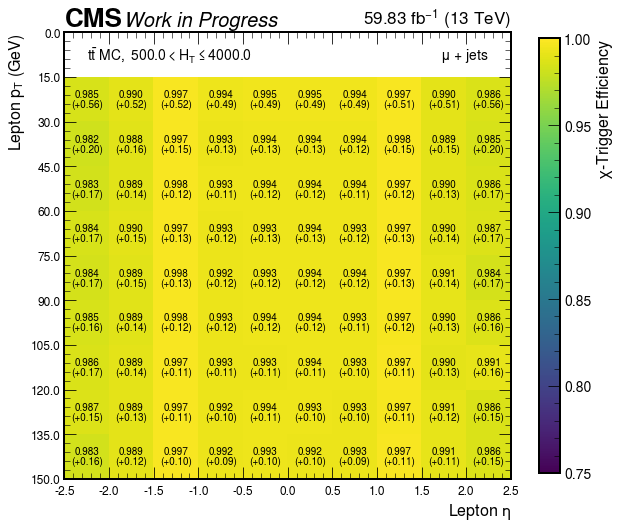

In [12]:
group = "ttbar"
tt_maskT  = ( np.array( total[ group ][ plotLep.value ] ) == 1 ) & ( np.array( total[ group ][ "AK4HT" ] ) > HT_lower ) & ( np.array( total[ group ][ "AK4HT" ] ) <= HT_upper )
tt_mask   = ( np.array( trigger[ group ][ plotLep.value ] ) == 1 ) & ( np.array( trigger[ group ][ "AK4HT" ] ) > HT_lower ) & ( np.array( trigger[ group ][ "AK4HT" ] ) <= HT_upper )
tt_maskX  = ( np.array( triggerX[ group ][ plotLep.value ] ) == 1 ) & ( np.array( triggerX[ group ][ "AK4HT" ] ) > HT_lower ) & ( np.array( triggerX[ group ][ "AK4HT" ] ) <= HT_upper )

hist_trigger = np.histogram2d(
    np.array( trigger[group]["leptonPt_MultiLepCalc"] )[ tt_mask ], 
    np.array( trigger[group]["leptonEta_MultiLepCalc"] )[ tt_mask ],
    bins = [ bins["PT"], bins["ETA"] ],
)
hist_triggerX = np.histogram2d(
    np.array( triggerX[group]["leptonPt_MultiLepCalc"] )[ tt_maskX ], 
    np.array( triggerX[group]["leptonEta_MultiLepCalc"] )[ tt_maskX ],
    bins = [ bins["PT"], bins["ETA"] ],
)
hist_total    = np.histogram2d(
    np.array( total[group]["leptonPt_MultiLepCalc"] )[ tt_maskT ], 
    np.array( total[group]["leptonEta_MultiLepCalc"] )[ tt_maskT ],
    bins = [ bins["PT"], bins["ETA"] ],
)

eff = hist_trigger[0] / hist_total[0]
effX = hist_triggerX[0] / hist_total[0]
eff_diff = effX - eff

plt.style.use( hep.style.CMS )
plt.figure()
hep.cms.text( "Work in Progress", fontsize = 20 )
hep.cms.lumitext( lumi[ year.value ] + " $fb^{-1}$ (13 TeV)", fontsize = 18 )
plt.imshow( effX, vmin = 0.75, vmax = 1.0 )
cbar = plt.colorbar( shrink = 0.8 )
cbar.ax.set_ylabel( "$\chi$-Trigger Efficiency", fontsize = 16 )
cbar.ax.tick_params( labelsize = 14 )
plt.xlabel( "Lepton $\eta$", fontsize = 16 )
plt.xticks( np.linspace( -0.5, len(bins["ETA"]) - 1.5, 11 ), labels = np.linspace(bins["ETA"][0],bins["ETA"][-1],11), fontsize = 12 )
plt.ylabel( "Lepton $p_T$ (GeV)", fontsize = 16 )
plt.yticks( np.linspace( -0.5, len( bins["PT"] ) - 1.5 , 11 ), labels = np.linspace( bins["PT"][0], bins["PT"][-1], 11 ), fontsize = 12  )
for i in range( effX.shape[0] ):
    for j in range( effX.shape[1] ):
        color = "black" if effX[j][i] > 0.83 else "white"
        plt.text( i, j, "{:.3f}".format( effX[j][i] ), fontsize = 10, ha = "center", va = "bottom", color = color )
        plt.text( i, j, "(+{:.2f})".format( eff_diff[j][i] ), fontsize = 10, ha = "center", va = "top", color = color )
plt.text( 9, 0, "e + jets" if plotLep.value == "isElectron" else "$\mu$ + jets", ha = "right", va = "center", fontsize = 14 )
plt.text( 0, 0, r"$t\bar{t}" + "\ MC,\ {}<H_T\leq{}$".format( HT_lower, HT_upper ), ha = "left", va = "center", fontsize = 14 )
plt.savefig( os.path.join( dirPath, "triggerX_efficiency_{}_{}_HT{}to{}_{}.png".format( group, plotLep.value, int(HT_lower), int(HT_upper), year.value ) ) )
plt.show()

## Calculate trigger efficiency and gain for data

/tmp/ipykernel_1106/1396870376.py:22: RuntimeWarning: invalid value encountered in divide
  eff = hist_trigger[0] / hist_total[0]
/tmp/ipykernel_1106/1396870376.py:23: RuntimeWarning: invalid value encountered in divide
  effX = hist_triggerX[0] / hist_total[0]


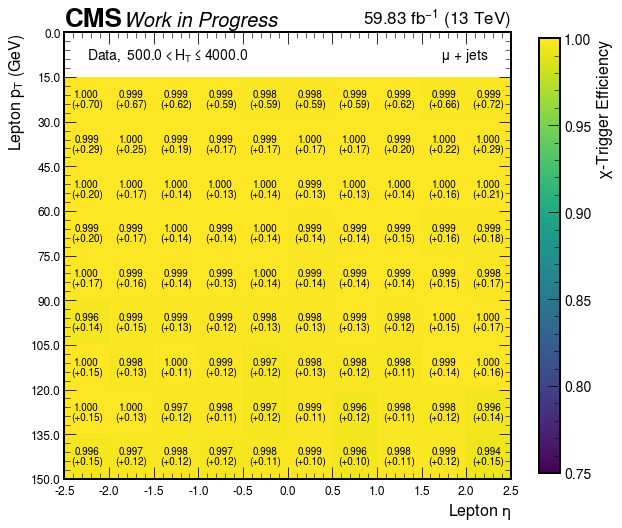

In [13]:
group = "DataE" if plotLep.value == "isElectron" else "DataM"
data_maskT  = ( np.array( total[ group ][ plotLep.value ] ) == 1 ) & ( np.array( total[ group ][ "AK4HT" ] ) > HT_lower ) & ( np.array( total[ group ][ "AK4HT" ] ) <= HT_upper )
data_mask   = ( np.array( trigger[ group ][ plotLep.value ] ) == 1 ) & ( np.array( trigger[ group ][ "AK4HT" ] ) > HT_lower ) & ( np.array( trigger[ group ][ "AK4HT" ] ) <= HT_upper )
data_maskX  = ( np.array( triggerX[ group ][ plotLep.value ] ) == 1 ) & ( np.array( triggerX[ group ][ "AK4HT" ] ) > HT_lower ) & ( np.array( triggerX[ group ][ "AK4HT" ] ) <= HT_upper )

hist_triggerX = np.histogram2d(
    np.array( triggerX[group]["leptonPt_MultiLepCalc"] )[ data_maskX ], 
    np.array( triggerX[group]["leptonEta_MultiLepCalc"] )[ data_maskX ],
    bins = [ bins["PT"], bins["ETA"] ], 
)
hist_total    = np.histogram2d(
    np.array( total[group]["leptonPt_MultiLepCalc"] )[ data_maskT ], 
    np.array( total[group]["leptonEta_MultiLepCalc"] )[ data_maskT ],
    bins = [ bins["PT"], bins["ETA"] ],
)
hist_trigger = np.histogram2d(
    np.array( trigger[group]["leptonPt_MultiLepCalc"] )[ data_mask ], 
    np.array( trigger[group]["leptonEta_MultiLepCalc"] )[ data_mask ],
    bins = [ bins["PT"], bins["ETA"] ], 
)

eff = hist_trigger[0] / hist_total[0]
effX = hist_triggerX[0] / hist_total[0]
eff_diff = effX - eff

plt.style.use( hep.style.CMS )
plt.figure()
hep.cms.text( "Work in Progress", fontsize = 20 )
hep.cms.lumitext( lumi[ year.value ] + " $fb^{-1}$ (13 TeV)", fontsize = 18 )
plt.imshow( effX, vmin = 0.75, vmax = 1.0 )
cbar = plt.colorbar( shrink = 0.8 )
cbar.ax.set_ylabel( "$\chi$-Trigger Efficiency", fontsize = 16 )
cbar.ax.tick_params( labelsize = 14 )
plt.xlabel( "Lepton $\eta$", fontsize = 16 )
plt.xticks( np.linspace( -0.5, len(bins["ETA"]) - 1.5, 11 ), labels = np.linspace(bins["ETA"][0],bins["ETA"][-1],11), fontsize = 12 )
plt.ylabel( "Lepton $p_T$ (GeV)", fontsize = 16 )
plt.yticks( np.linspace( -0.5, len( bins["PT"] ) - 1.5 , 11 ), labels = np.linspace( bins["PT"][0], bins["PT"][-1], 11 ), fontsize = 12  )
for i in range( eff.shape[0] ):
    for j in range( eff.shape[1] ):
        color = "black" if effX[j][i] > 0.83 else "white"
        plt.text( i, j, "{:.3f}".format( effX[j][i] ), fontsize = 10, ha = "center", va = "bottom", color = color )
        plt.text( i, j, "(+{:.2f})".format( eff_diff[j][i] ), fontsize = 10, ha = "center", va = "top", color = color )
plt.text( 9, 0, "e + jets" if plotLep.value == "isElectron" else "$\mu$ + jets", ha = "right", va = "center", fontsize = 14 )
plt.text( 0, 0, r"$Data,\ {}<H_T\leq{}$".format( HT_lower, HT_upper ), ha = "left", va = "center", fontsize = 14 )
plt.savefig( os.path.join( dirPath, "triggerX_efficiency_{}_{}_HT{}to{}_{}.png".format( group, plotLep.value, int(HT_lower), int(HT_upper), year.value ) ) )
plt.show()

## Plot scale factors

In [ ]:
def efficiency_err( n, ntot ):
    return np.sqrt( ( ( n + 1 ) * ( n + 2 ) ) / ( ( ntot + 2 ) * ( ntot + 3 ) ) - ( n + 1 )**2 / ( ntot + 2 )**2 )

def ratio_err( x, xerr, y, yerr ):
    return np.sqrt( ( xerr / y )**2 + ( x*yerr / y**2 )**2 )

In [ ]:
group = "DataE" if plotLep.value == "isElectron" else "DataM"

mc_triggerX = np.histogram2d(
    np.array( triggerX["ttbar"]["leptonPt_MultiLepCalc"] )[ tt_maskX ], 
    np.array( triggerX["ttbar"]["leptonEta_MultiLepCalc"] )[ tt_maskX ],
    bins = [ bins["PT"], bins["ETA"] ], 
    weights = np.array( triggerX["ttbar"]["weight"] )[ tt_maskX ]
)
mc_total    = np.histogram2d(
    np.array( total["ttbar"]["leptonPt_MultiLepCalc"] )[ tt_maskT ], 
    np.array( total["ttbar"]["leptonEta_MultiLepCalc"] )[ tt_maskT ],
    bins = [ bins["PT"], bins["ETA"] ], 
    weights = np.array( total["ttbar"]["weight"] )[ tt_maskT ]
)

data_triggerX = np.histogram2d(
    np.array( triggerX[group]["leptonPt_MultiLepCalc"] )[ data_maskX ], 
    np.array( triggerX[group]["leptonEta_MultiLepCalc"] )[ data_maskX ],
    bins = [ bins["PT"], bins["ETA"] ], 
    weights = np.array( triggerX[group]["weight"] )[ data_maskX ]
)
data_total    = np.histogram2d(
    np.array( total[group]["leptonPt_MultiLepCalc"] )[ data_maskT ], 
    np.array( total[group]["leptonEta_MultiLepCalc"] )[ data_maskT ],
    bins = [ bins["PT"], bins["ETA"] ], 
    weights = np.array( total[group]["weight"] )[ data_maskT ]
)

mc_eff = mc_triggerX[0] / mc_total[0]
mc_err = efficiency_err( mc_triggerX[0], mc_total[0] )
data_eff = data_triggerX[0] / data_total[0]
data_err = efficiency_err( data_triggerX[0], data_total[0] )
sf = np.nan_to_num( data_eff / mc_eff )
sf_err = np.nan_to_num( ratio_err( data_eff, data_err, mc_eff, mc_err ) )
sf_tot = ( np.sum( data_triggerX[0] ) / np.sum( data_total[0] ) ) / ( np.sum( mc_triggerX[0] ) / np.sum( mc_total[0] ) )
sf_tot_err = np.mean( 100. * sf_err / sf_tot )

plt.style.use( hep.style.CMS )
plt.figure()
hep.cms.text( "Preliminary", fontsize = 20 )
hep.cms.lumitext( lumi[ year.value ] + " $fb^{-1}$ (13 TeV)", fontsize = 18 )
plt.imshow( sf, vmin = 0.75, vmax = 1.25 )
cbar = plt.colorbar( shrink = 0.8 )
cbar.ax.set_ylabel( "$\chi$-Trigger Scale Factor", fontsize = 16 )
cbar.ax.tick_params( labelsize = 14 )
plt.xlabel( "Lepton $\eta$", fontsize = 16 )
plt.xticks( np.linspace(0,len(bins["ETA"])-2,11), labels = np.linspace(bins["ETA"][0],bins["ETA"][-1],11), fontsize = 12 )
plt.ylabel( "Lepton $p_T$ (GeV)", fontsize = 16 )
plt.yticks( np.linspace(0,len(bins["PT"])-2,11), labels = np.linspace(bins["PT"][0],bins["PT"][-1],11), fontsize = 12 )
for i in range( sf.shape[0] ):
    for j in range( sf.shape[1] ):
        if j == 0: continue
        if sf[j][i] > 3.0: continue
        color = "black" if sf[j][i] > 1.0 else "white"
        plt.text( i, j, "{:.3f}".format( sf[j][i] ), fontsize = 10, ha = "center", va = "bottom", color = color )
        plt.text( i, j, r"$\pm{:.3f}$".format( sf_err[j][i] ), fontsize = 10, ha = "center", va = "top", color = color )
plt.text( 9, 0, "e + jets" if plotLep.value == "isElectron" else "$\mu$ + jets", ha = "right", va = "center", color = "w", fontsize = 14 )
plt.text( 0, 0, r"{}<$H_T\leq{},$ ".format( HT_lower, HT_upper ) + r"$\overline{SF}=$" + "{:.3f}, ".format( sf_tot ) + r"$\sigma_{SF}=$" + "{:.2f}%".format( sf_tot_err ), ha = "left", va = "center", color = "w", fontsize = 14 )
plt.savefig( os.path.join( dirPath, "triggerX_sf_{}_{}_HT{}to{}_{}.png".format( group, plotLep.value, int(HT_lower), int(HT_upper), year.value ) ) )
plt.show()

### HT-dependent scale factors

In [ ]:
group = "DataE" if plotLep.value == "isElectron" else "DataM"
HT_bins = [350.,400.,500.,1000.,2000.]

sf_HT = []

for i in range( len( HT_bins ) - 1 ):
    tt_maskT    = ( np.array( total[ "ttbar" ][ plotLep.value ] ) == 1 ) & ( np.array( total[ "ttbar" ][ "AK4HT" ] ) > HT_bins[i] ) & ( np.array( total[ "ttbar" ][ "AK4HT" ] ) < HT_bins[i+1] )
    tt_maskX    = ( np.array( triggerX[ "ttbar" ][ plotLep.value ] ) == 1 ) & ( np.array( triggerX[ "ttbar" ][ "AK4HT" ] ) > HT_bins[i] ) & ( np.array( triggerX[ "ttbar" ][ "AK4HT" ] ) < HT_bins[i+1] )
    data_maskT  = ( np.array( total[ group ][ plotLep.value ] ) == 1 ) & ( np.array( total[ group ][ "AK4HT" ] ) > HT_bins[i] ) & ( np.array( total[ group ][ "AK4HT" ] ) < HT_bins[i+1] )
    data_maskX  = ( np.array( triggerX[ group ][ plotLep.value ] ) == 1 ) & ( np.array( triggerX[ group ][ "AK4HT" ] ) > HT_bins[i] ) & ( np.array( triggerX[ group ][ "AK4HT" ] ) < HT_bins[i+1] )
    mc_triggerX = np.histogram2d(
        np.array( triggerX["ttbar"]["leptonPt_MultiLepCalc"] )[ tt_maskX ], 
        np.array( triggerX["ttbar"]["leptonEta_MultiLepCalc"] )[ tt_maskX ],
        bins = [ bins["PT"], bins["ETA"] ], 
    )
    mc_total    = np.histogram2d(
        np.array( total["ttbar"]["leptonPt_MultiLepCalc"] )[ tt_maskT ], 
        np.array( total["ttbar"]["leptonEta_MultiLepCalc"] )[ tt_maskT ],
        bins = [ bins["PT"], bins["ETA"] ], 
    )

    data_triggerX = np.histogram2d(
        np.array( triggerX[group]["leptonPt_MultiLepCalc"] )[ data_maskX ], 
        np.array( triggerX[group]["leptonEta_MultiLepCalc"] )[ data_maskX ],
        bins = [ bins["PT"], bins["ETA"] ], 
    )
    data_total    = np.histogram2d(
        np.array( total[group]["leptonPt_MultiLepCalc"] )[ data_maskT ], 
        np.array( total[group]["leptonEta_MultiLepCalc"] )[ data_maskT ],
        bins = [ bins["PT"], bins["ETA"] ], 
    )
    mc_eff = mc_triggerX[0] / mc_total[0]
    data_eff = data_triggerX[0] / data_total[0]
    sf_HT.append( data_eff / mc_eff )
    

In [ ]:
sf_mean = np.mean( np.nan_to_num( sf_HT ), axis = 0 )
sf_std  = np.std( np.nan_to_num( sf_HT ), axis = 0 )

In [ ]:
plt.style.use( hep.style.CMS )
plt.figure()
hep.cms.text( "Preliminary", fontsize = 20 )
hep.cms.lumitext( lumi[ year.value ] + " $fb^{-1}$ (13 TeV)", fontsize = 18 )
plt.imshow( sf_mean, vmin = 0.75, vmax = 1.25 )
cbar = plt.colorbar( shrink = 0.8 )
cbar.ax.set_ylabel( "$\chi$-Trigger Scale Factor", fontsize = 16 )
cbar.ax.tick_params( labelsize = 14 )
plt.xlabel( "Lepton $\eta$", fontsize = 16 )
plt.xticks( np.linspace(0,len(bins["ETA"])-2,11), labels = np.linspace(bins["ETA"][0],bins["ETA"][-1],11), fontsize = 12 )
plt.ylabel( "Lepton $p_T$ (GeV)", fontsize = 16 )
plt.yticks( np.linspace(0,len(bins["PT"])-2,11), labels = np.linspace(bins["PT"][0],bins["PT"][-1],11), fontsize = 12 )
for i in range( sf.shape[0] ):
    for j in range( sf.shape[1] ):
        if j == 0: continue
        color = "black" if sf_mean[j][i] > 1.0 else "white"
        if sf_std[j][i] / sf_mean[j][i] > 0.1: color = "red"
        plt.text( i, j, "{:.3f}".format( sf_mean[j][i] ), fontsize = 10, ha = "center", va = "bottom", color = color )
        plt.text( i, j, "{:.3f}".format( sf_std[j][i] ), fontsize = 10, ha = "center", va = "top", color = color )
plt.text( 9, 0, "e + jets" if plotLep.value == "isElectron" else "$\mu$ + jets", ha = "right", va = "center", color = "w", fontsize = 14 )
plt.text( 0, 0, r"$H_T={}$".format( HT_bins ), ha = "left", va = "center", color = "w", fontsize = 14 )
plt.savefig( os.path.join( dirPath, "triggerX_sf_{}_{}_HT_Average_{}.png".format( group, plotLep.value, year.value ) ) )
plt.show()

## Trigger SF dependence on HT

In [ ]:
group = "DataE" if plotLep.value == "isElectron" else "DataM"
HT_bins = [ 0, 350, 400, 450, 500, 600, 700, 800, 900, 1000, 1500, 2000, 3000, 3500 ]

tt_maskT    = ( np.array( total[ "ttbar" ][ plotLep.value ] ) == 1 ) 
tt_maskX    = ( np.array( triggerX[ "ttbar" ][ plotLep.value ] ) == 1 ) 
data_maskT  = ( np.array( total[ group ][ plotLep.value ] ) == 1 ) 
data_maskX  = ( np.array( triggerX[ group ][ plotLep.value ] ) == 1 ) 
mc_triggerX = np.histogram(
    np.array( triggerX["ttbar"]["AK4HT"] )[ tt_maskX ], 
    bins = HT_bins, 
    weights = np.array( triggerX["ttbar"]["weight"] )[ tt_maskX ]
)
mc_total    = np.histogram(
    np.array( total["ttbar"]["AK4HT"] )[ tt_maskT ], 
    bins = HT_bins, 
    weights = np.array( total["ttbar"]["weight"] )[ tt_maskT ]
)

data_triggerX = np.histogram(
    np.array( triggerX[group]["AK4HT"] )[ data_maskX ], 
    bins = HT_bins, 
    weights = np.array( triggerX[group]["weight"] )[ data_maskX ]
)
data_total    = np.histogram(
    np.array( total[group]["AK4HT"] )[ data_maskT ], 
    bins = HT_bins, 
    weights = np.array( total[group]["weight"] )[ data_maskT ]
)

mc_eff = mc_triggerX[0] / mc_total[0]
mc_err = efficiency_err( mc_triggerX[0], mc_total[0] )
data_eff = data_triggerX[0] / data_total[0]
data_err = efficiency_err( data_triggerX[0], data_total[0] )
sf_HT = np.nan_to_num( data_eff / mc_eff )[1:]
sf_HT_err = np.nan_to_num( ratio_err( data_eff, data_err, mc_eff, mc_err ) )[1:]
del mc_triggerX, mc_total, data_triggerX, data_total

### Calculate for lepton pT < 50 GeV

In [ ]:
lep_cut = 50
tt_maskT_lep    = ( np.array( total[ "ttbar" ][ plotLep.value ] ) == 1 ) & ( np.array( total[ "ttbar" ][ "leptonPt_MultiLepCalc" ] ) < lep_cut )
tt_maskX_lep    = ( np.array( triggerX[ "ttbar" ][ plotLep.value ] ) == 1 ) & ( np.array( triggerX[ "ttbar" ][ "leptonPt_MultiLepCalc" ] ) < lep_cut )
data_maskT_lep  = ( np.array( total[ group ][ plotLep.value ] ) == 1 ) & ( np.array( total[ group ][ "leptonPt_MultiLepCalc" ] ) < lep_cut )
data_maskX_lep  = ( np.array( triggerX[ group ][ plotLep.value ] ) == 1 ) & ( np.array( triggerX[ group ][ "leptonPt_MultiLepCalc" ] ) < lep_cut )
mc_triggerX_lep = np.histogram(
    np.array( triggerX["ttbar"]["AK4HT"] )[ tt_maskX_lep ], 
    bins = HT_bins, 
    weights = np.array( triggerX["ttbar"]["weight"] )[ tt_maskX_lep ]
)
mc_total_lep    = np.histogram(
    np.array( total["ttbar"]["AK4HT"] )[ tt_maskT_lep ], 
    bins = HT_bins, 
    weights = np.array( total["ttbar"]["weight"] )[ tt_maskT_lep ]
)

data_triggerX_lep = np.histogram(
    np.array( triggerX[group]["AK4HT"] )[ data_maskX_lep ], 
    bins = HT_bins, 
    weights = np.array( triggerX[group]["weight"] )[ data_maskX_lep ]
)
data_total_lep    = np.histogram(
    np.array( total[group]["AK4HT"] )[ data_maskT_lep ], 
    bins = HT_bins, 
    weights = np.array( total[group]["weight"] )[ data_maskT_lep ]
)

mc_eff_lep = mc_triggerX_lep[0] / mc_total_lep[0]
mc_err_lep = efficiency_err( mc_triggerX_lep[0], mc_total_lep[0] )
data_eff_lep = data_triggerX_lep[0] / data_total_lep[0]
data_err_lep = efficiency_err( data_triggerX_lep[0], data_total_lep[0] )
sf_HT_lep = np.nan_to_num( data_eff_lep / mc_eff_lep )[1:]
sf_HT_err_lep = np.nan_to_num( ratio_err( data_eff_lep, data_err_lep, mc_eff_lep, mc_err_lep ) )[1:]
del mc_triggerX_lep, mc_total_lep, data_triggerX_lep, data_total_lep

In [ ]:
plt.style.use( hep.style.CMS )
plt.figure( figsize = ( 6, 6 ) )
hep.cms.text( "Preliminary", fontsize = 20 )
hep.cms.lumitext( lumi[ year.value ] + " $fb^{-1}$ (13 TeV)", fontsize = 18 )
plt.step( HT_bins[:-1], mc_eff, where = "pre", label = "MC" )
plt.fill_between( HT_bins[:-1], mc_eff - mc_err, mc_eff + mc_err, step = "pre", alpha = 0.2,  )
plt.step( HT_bins[:-1], data_eff, where = "pre", label = "Data" )
plt.fill_between( HT_bins[:-1], data_eff - data_err, data_eff + data_err, step = "pre", alpha = 0.2,  )
plt.xlabel( r"$H_T$ (GeV)", fontsize = 16 )
plt.xlim( 350, 3000 )
plt.ylabel( "Efficiency", fontsize = 16 )
plt.ylim( 0.82 , 1.03 )
plt.annotate( "e + jets" if plotLep.value == "isElectron" else "$\mu$ + jets", ( 0.95, 0.95 ), xycoords = "axes fraction", ha = "right", va = "top", color = "k", fontsize = 14 )
plt.legend( loc = 2, fontsize = 12 )
plt.grid( which = "both" )
plt.minorticks_on()
plt.savefig( os.path.join( dirPath, "triggerX_efficiency_{}_{}_HT_1D_{}.png".format( group, plotLep.value, year.value ) ) )
plt.show()

In [ ]:
plt.style.use( hep.style.CMS )
plt.figure( figsize = ( 6, 6 ) )
hep.cms.text( "Preliminary", fontsize = 20 )
hep.cms.lumitext( lumi[ year.value ] + " $fb^{-1}$ (13 TeV)", fontsize = 18 )
plt.step( HT_bins[1:-1], sf_HT, where = "pre", label = r"$p_T^\ell>20\ GeV$" )
plt.fill_between( HT_bins[1:-1], sf_HT - sf_HT_err, sf_HT + sf_HT_err, step = "pre", alpha = 0.2,  )
plt.step( HT_bins[1:-1], sf_HT_lep, where = "pre", label = r"${}>p_T^\ell>20\ GeV$".format( lep_cut ) )
plt.fill_between( HT_bins[1:-1], sf_HT_lep - sf_HT_err_lep, sf_HT_lep + sf_HT_err_lep, step = "pre", alpha = 0.2,  )
plt.xlabel( r"$H_T$ (GeV)", fontsize = 16 )
plt.xlim( 350, 3000 )
plt.ylabel( "Scale Factor", fontsize = 16 )
plt.ylim( 0.84 , 1.16 )
plt.annotate( "e + jets" if plotLep.value == "isElectron" else "$\mu$ + jets", ( 0.95, 0.95 ), xycoords = "axes fraction", ha = "right", va = "top", color = "k", fontsize = 14 )
plt.legend( loc = 2, fontsize = 12 )
plt.grid( which = "both" )
plt.minorticks_on()
plt.savefig( os.path.join( dirPath, "triggerX_sf_{}_{}_HT_1D_{}.png".format( group, plotLep.value, year.value ) ) )
plt.show()